In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import datetime


Plotting the updated discharge at Chache from Kasteel 


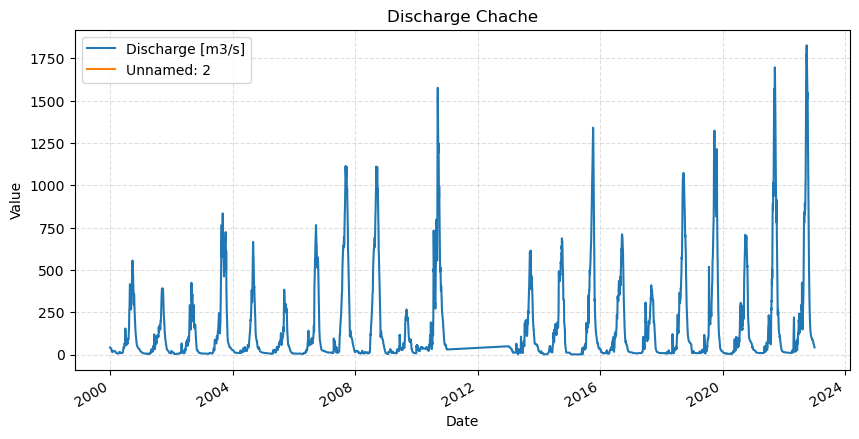

            Discharge [m3/s]  Unnamed: 2                   Unnamed: 3
Date                                                                 
2000-01-01         41.117250         NaN  years 2011 and 2012 missing
2000-01-02         40.616936         NaN                          NaN
2000-01-03         40.545840         NaN                     0.129438
2000-01-04         40.049721         NaN                          NaN
2000-01-05         39.978442         NaN                          NaN
...                      ...         ...                          ...
2022-12-27         51.900109         NaN                          NaN
2022-12-28         49.654936         NaN                          NaN
2022-12-29         46.747499         NaN                          NaN
2022-12-30         43.937847         NaN                          NaN
2022-12-31         41.894346         NaN                          NaN

[7670 rows x 3 columns]


In [34]:

file_path = "C:/Users/flavi/OneDrive - Delft University of Technology/code_giannini_thesis/Thesis/All data1.xlsx"
Data_Chance = pd.read_excel(file_path, sheet_name="Discharge Chache", parse_dates=["Date"])
Data_Chance.set_index("Date", inplace=True)
Data_Chance.sort_index(inplace=True)

Data_Chance.plot(figsize=(10, 5), title="Discharge Chache")
plt.xlabel("Date")
plt.ylabel("Value")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.show()
print(Data_Chance)


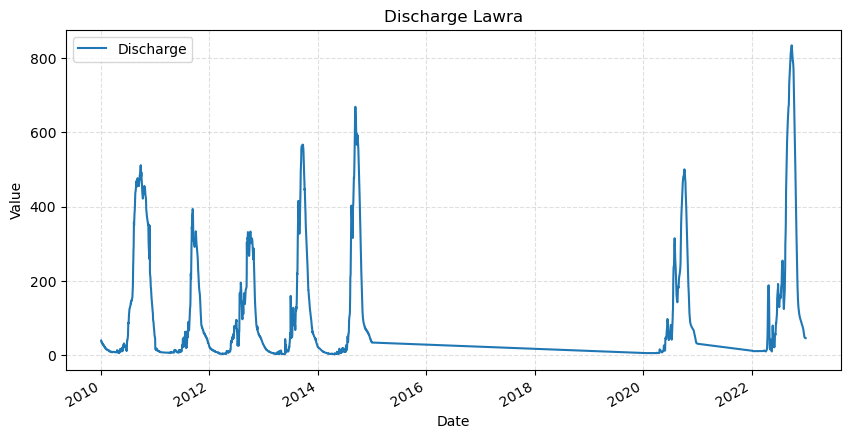

In [33]:
file_path = "C:/Users/flavi/OneDrive - Delft University of Technology/code_giannini_thesis/Thesis/All data1.xlsx"
Data_Lawra = pd.read_excel(file_path, sheet_name="Discharge Lawra", parse_dates=["Date"])
Data_Lawra.set_index("Date", inplace=True)
Data_Lawra.sort_index(inplace=True)

Data_Lawra.plot(figsize=(10, 5), title="Discharge Lawra")
plt.xlabel("Date")
plt.ylabel("Value")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.show()

Plotting Precipitation data interpolated for the different basins from meteorological agency of Burkina Faso 

In [9]:
file_path_prec = "C:/Users/flavi/OneDrive - Delft University of Technology/code_giannini_thesis/Thesis/All data1.xlsx"
Prec = pd.read_excel(file_path_prec, sheet_name="Precipitation", parse_dates=["Date"])
Prec.set_index("Date", inplace=True)
Prec.sort_index(inplace=True)

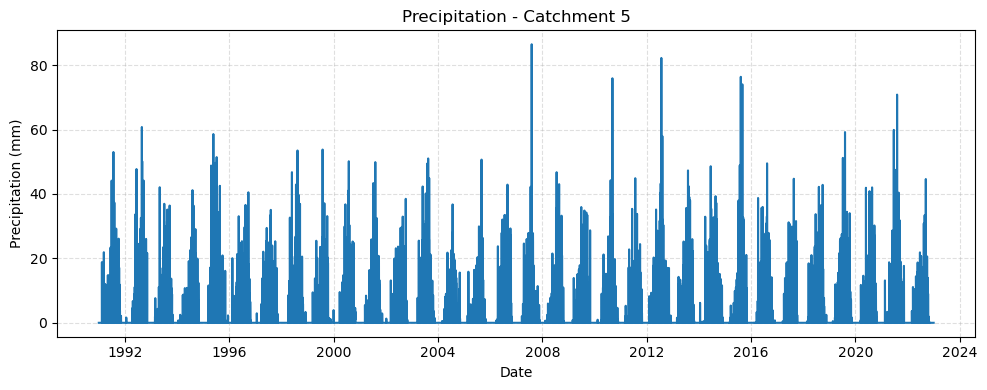

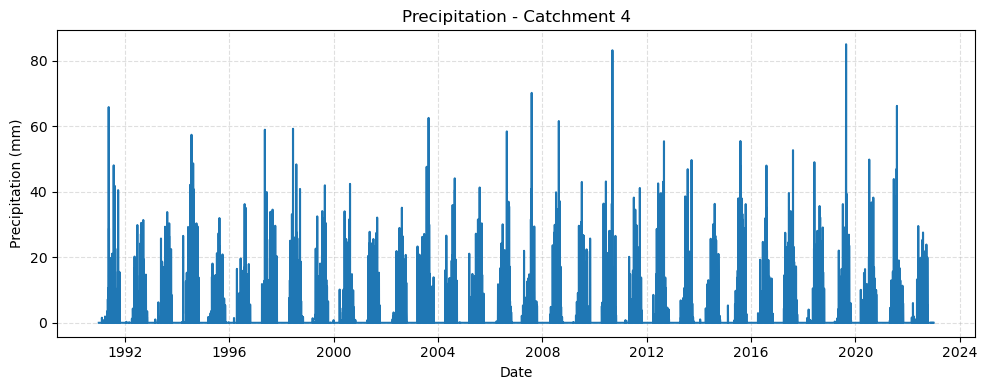

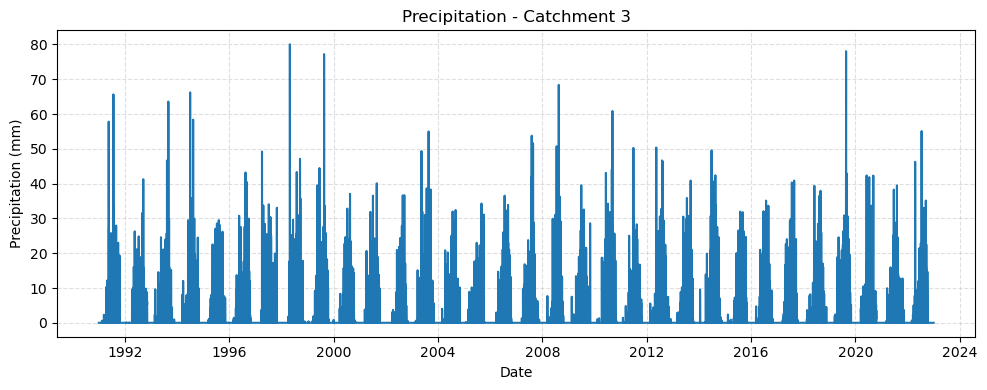

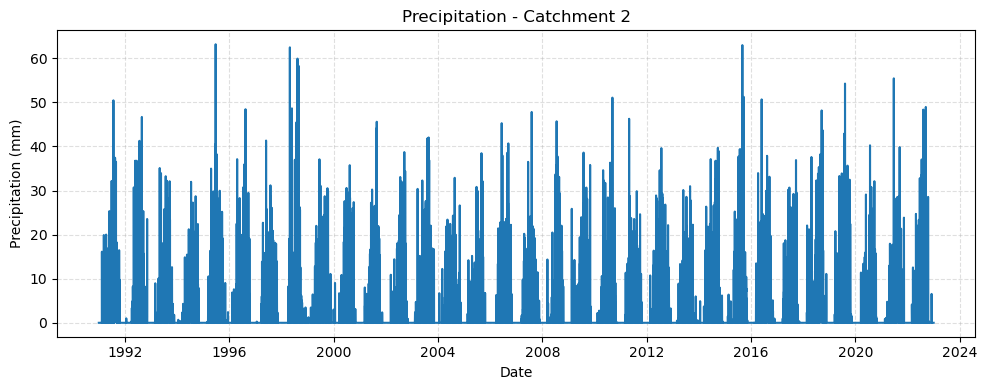

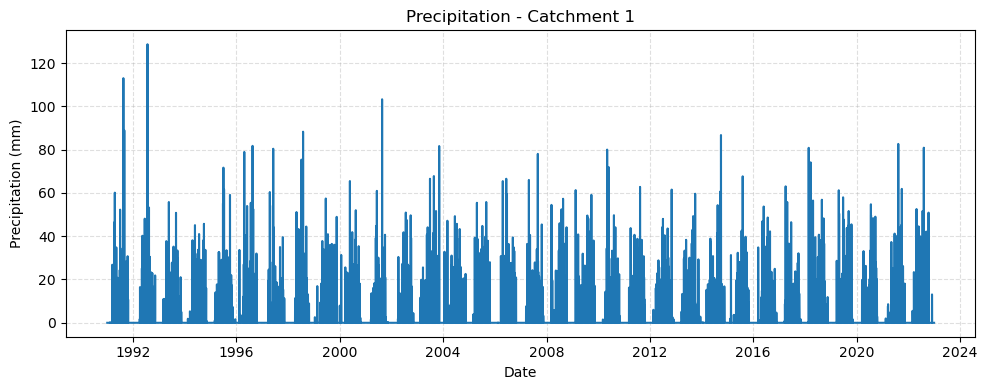

In [19]:
# Plot each precipitation catchment separately (Catchment 5 to 1)
selected_columns = list(Prec.columns[:5])  # assumed order: C5, C4, C3, C2, C1
for catchment_number, column in zip(range(5, 0, -1), selected_columns):
    plt.figure(figsize=(10, 4))
    plt.plot(Prec.index, Prec[column], color="tab:blue")
    plt.title(f"Precipitation - Catchment {catchment_number}")
    plt.xlabel("Date")
    plt.ylabel("Precipitation (mm)")
    plt.grid(True, which="both", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

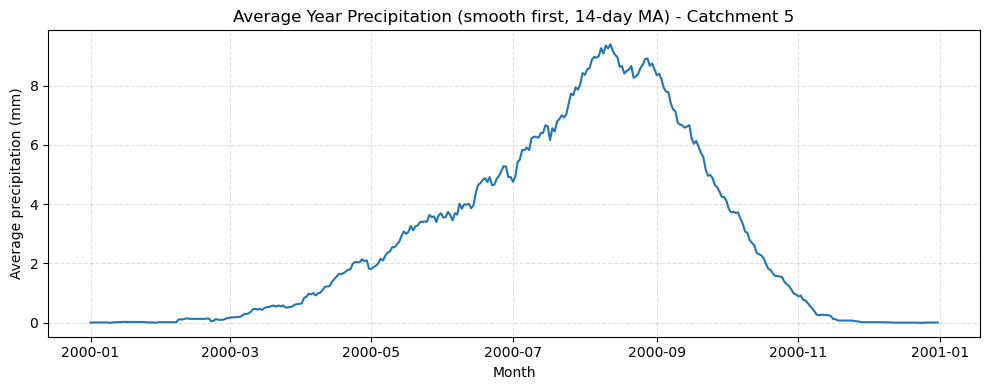

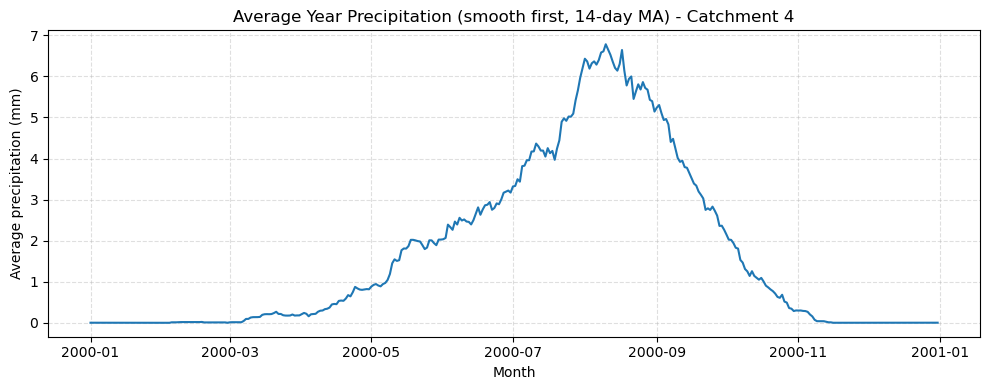

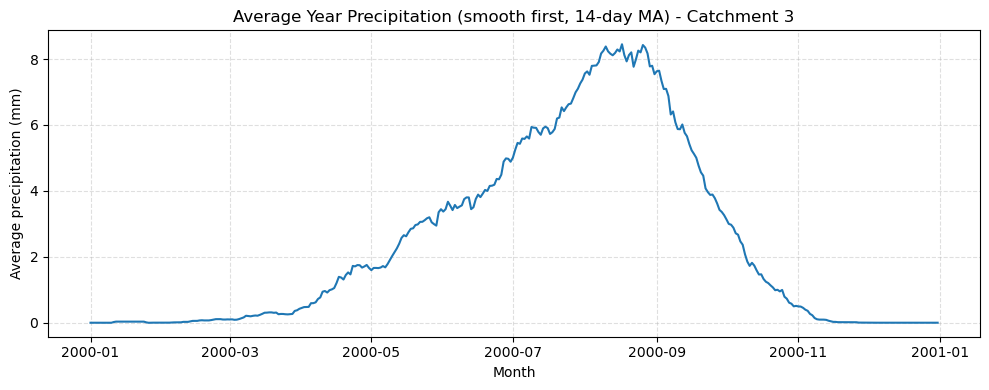

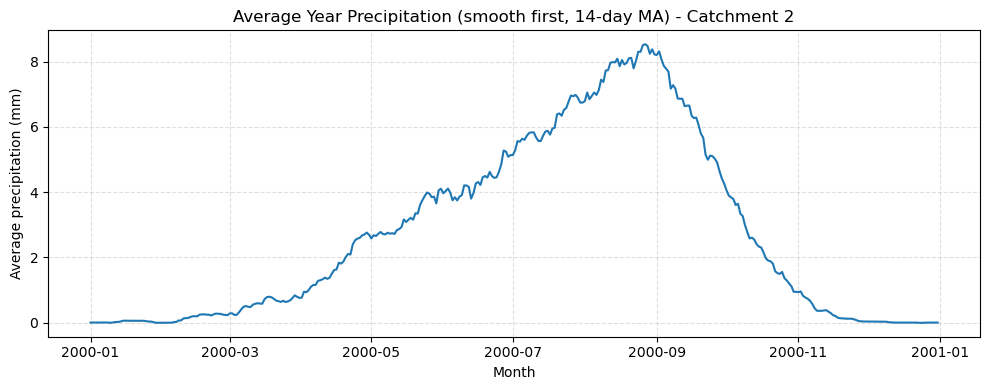

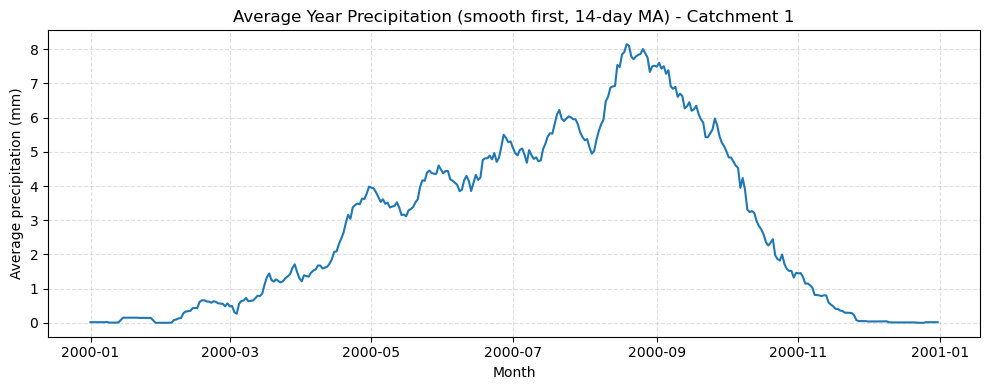

In [20]:
# Average year for precipitation - smooth first, then group (Catchments 5 to 1)
selected_columns = list(Prec.columns[:5])  # assumed order: C5, C4, C3, C2, C1
prec_selected = Prec[selected_columns].copy()

# Smooth the original daily series with a 14-day moving average
prec_smoothed = prec_selected.rolling(window=14, center=True, min_periods=1).mean()

# Mean precipitation for each calendar day across all years (after smoothing)
daily_climatology = prec_smoothed.groupby([prec_smoothed.index.month, prec_smoothed.index.day]).mean()

# Build a dummy leap-year date index so Feb 29 is supported when present
daily_climatology.index = pd.to_datetime(
    [f"2000-{month:02d}-{day:02d}" for month, day in daily_climatology.index]
)
daily_climatology.sort_index(inplace=True)

for catchment_number, column in zip(range(5, 0, -1), selected_columns):
    plt.figure(figsize=(10, 4))
    plt.plot(daily_climatology.index, daily_climatology[column], color="tab:blue")
    plt.title(f"Average Year Precipitation (smooth first, 14-day MA) - Catchment {catchment_number}")
    plt.xlabel("Month")
    plt.ylabel("Average precipitation (mm)")
    plt.grid(True, which="both", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

In [35]:
# Rainfall value on 14 Feb 1991 for Catchment 5
selected_columns = list(Prec.columns[:5])  # assumed order: C5, C4, C3, C2, C1
catchment_5_column = selected_columns[0]
target_date = pd.Timestamp("1991-02-14")

if target_date not in Prec.index:
    raise ValueError(f"Date {target_date.date()} not found in Prec index")

rain_value = Prec.loc[target_date, catchment_5_column]
rain_value

18.82400102995974

Correlation Analysis 

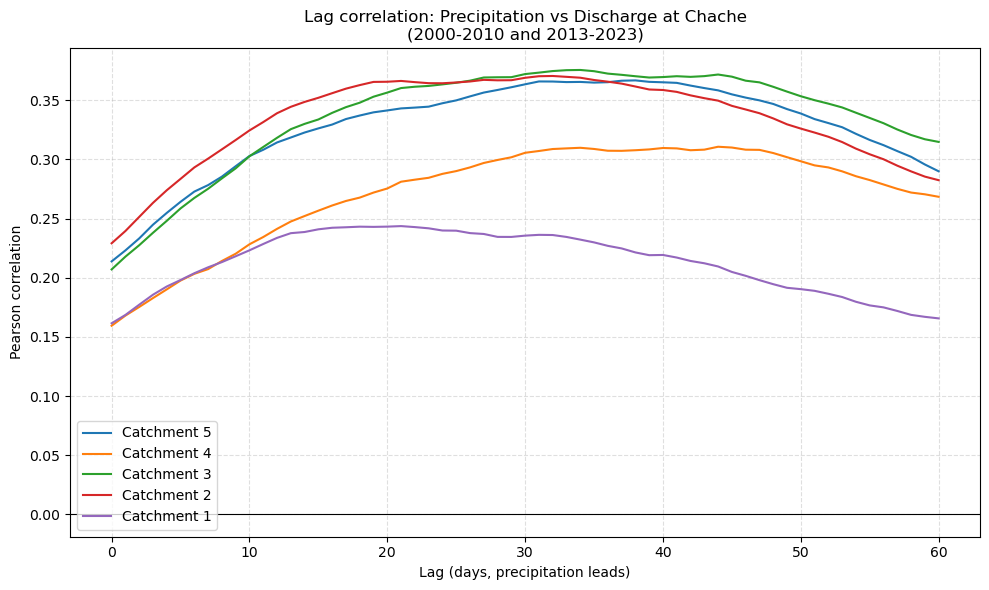

,Catchment,Best lag (days),Correlation at best lag
0,5,38,0.366766
1,4,44,0.310707
2,3,34,0.375583
3,2,32,0.370497
4,1,21,0.243662


In [36]:
# Correlation time-lag analysis: precipitation (catchments) vs discharge at Chache

# Use first numeric discharge column
discharge_col = Data_Chance.select_dtypes(include=[np.number]).columns[0]
q = Data_Chance[discharge_col].rename("Q_chache")

# Keep first 5 precipitation columns (assumed order: Catchment 5,4,3,2,1)
prec_cols = list(Prec.columns[:5])
prec_subset = Prec[prec_cols].copy()

# Keep only years 2000-2010 and 2013-2023 (apply mask to each dataset separately)
valid_years_q = ((q.index.year >= 2000) & (q.index.year <= 2010)) | ((q.index.year >= 2013) & (q.index.year <= 2023))
valid_years_p = ((prec_subset.index.year >= 2000) & (prec_subset.index.year <= 2010)) | ((prec_subset.index.year >= 2013) & (prec_subset.index.year <= 2023))
q = q.loc[valid_years_q]
prec_subset = prec_subset.loc[valid_years_p]

# Align datasets on common dates
common_index = q.index.intersection(prec_subset.index)
q = q.loc[common_index]
prec_subset = prec_subset.loc[common_index]

# Lag analysis settings (precipitation leading discharge by lag days)
max_lag_days = 60
lags = np.arange(0, max_lag_days + 1)

corr_by_catchment = {}
summary_rows = []

for catchment_number, col in zip(range(5, 0, -1), prec_cols):
    corr_values = []
    for lag in lags:
        # precip(t-lag) vs discharge(t)
        r = q.corr(prec_subset[col].shift(lag))
        corr_values.append(r)

    corr_series = pd.Series(corr_values, index=lags, name=f"Catchment {catchment_number}")
    corr_by_catchment[catchment_number] = corr_series

    best_lag = corr_series.abs().idxmax()
    best_corr = corr_series.loc[best_lag]
    summary_rows.append({
        "Catchment": catchment_number,
        "Best lag (days)": int(best_lag),
        "Correlation at best lag": best_corr
    })

# Plot correlation vs lag for each catchment
plt.figure(figsize=(10, 6))
for catchment_number in range(5, 0, -1):
    plt.plot(
        corr_by_catchment[catchment_number].index,
        corr_by_catchment[catchment_number].values,
        label=f"Catchment {catchment_number}"
    )

plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Lag (days, precipitation leads)")
plt.ylabel("Pearson correlation")
plt.title("Lag correlation: Precipitation vs Discharge at Chache\n(2000-2010 and 2013-2023)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# Summary table
lag_summary = pd.DataFrame(summary_rows).sort_values("Catchment", ascending=False)
lag_summary

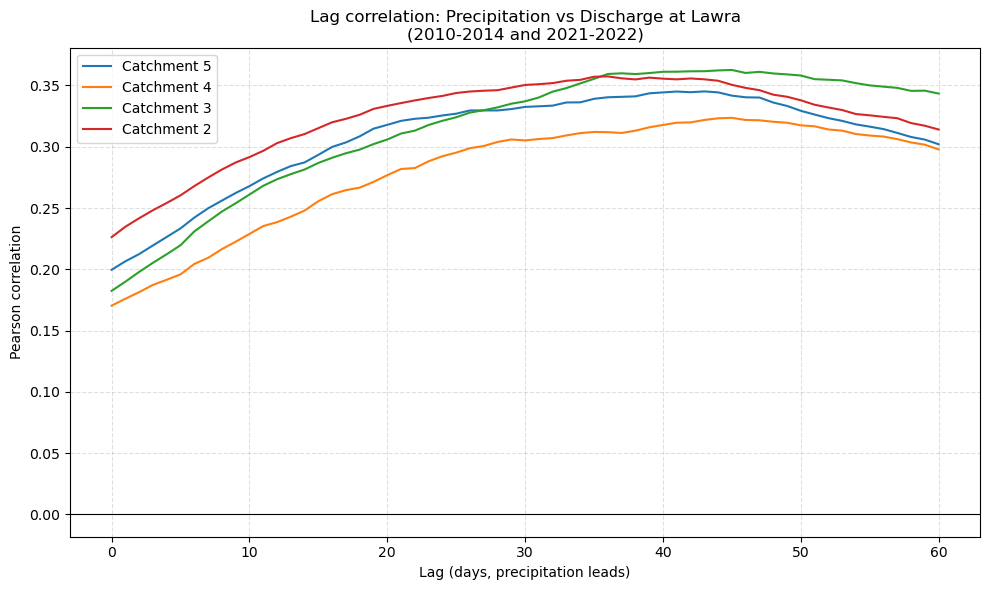

,Catchment,Best lag (days),Correlation at best lag
0,5,43,0.345155
1,4,45,0.323582
2,3,45,0.362655
3,2,36,0.357383


In [37]:



# Use first numeric discharge column
discharge_col_lawra = Data_Lawra.select_dtypes(include=[np.number]).columns[0]
q_lawra = Data_Lawra[discharge_col_lawra].rename("Q_lawra")

# Use precipitation already loaded (exclude Catchment 1 -> keep Catchments 5,4,3,2)
prec_cols = list(Prec.columns[:4])
prec_subset = Prec[prec_cols].copy()

# Keep only years 2010-2014 and 2021-2022
valid_years_q = ((q_lawra.index.year >= 2010) & (q_lawra.index.year <= 2014)) | ((q_lawra.index.year >= 2021) & (q_lawra.index.year <= 2022))
valid_years_p = ((prec_subset.index.year >= 2010) & (prec_subset.index.year <= 2014)) | ((prec_subset.index.year >= 2021) & (prec_subset.index.year <= 2022))
q_lawra = q_lawra.loc[valid_years_q]
prec_subset = prec_subset.loc[valid_years_p]

# Align datasets on common dates
common_index = q_lawra.index.intersection(prec_subset.index)
q_lawra = q_lawra.loc[common_index]
prec_subset = prec_subset.loc[common_index]

# Lag settings (precipitation leading discharge by lag days)
max_lag_days = 60
lags = np.arange(0, max_lag_days + 1)

corr_by_catchment_lawra = {}
summary_rows_lawra = []

for catchment_number, col in zip(range(5, 1, -1), prec_cols):
    corr_values = []
    for lag in lags:
        r = q_lawra.corr(prec_subset[col].shift(lag))
        corr_values.append(r)

    corr_series = pd.Series(corr_values, index=lags, name=f"Catchment {catchment_number}")
    corr_by_catchment_lawra[catchment_number] = corr_series

    best_lag = corr_series.abs().idxmax()
    best_corr = corr_series.loc[best_lag]
    summary_rows_lawra.append({
        "Catchment": catchment_number,
        "Best lag (days)": int(best_lag),
        "Correlation at best lag": best_corr
    })

# Plot correlation vs lag for each catchment
plt.figure(figsize=(10, 6))
for catchment_number in range(5, 1, -1):
    plt.plot(
        corr_by_catchment_lawra[catchment_number].index,
        corr_by_catchment_lawra[catchment_number].values,
        label=f"Catchment {catchment_number}"
    )

plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Lag (days, precipitation leads)")
plt.ylabel("Pearson correlation")
plt.title("Lag correlation: Precipitation vs Discharge at Lawra\n(2010-2014 and 2021-2022)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# Summary table
lag_summary_lawra = pd.DataFrame(summary_rows_lawra).sort_values("Catchment", ascending=False)
lag_summary_lawra

PROBABILITY DISTRIBUTION ACCROSS THE ALL BASIN

Rainfall summary across all basins (mm):


,Value
count,58438.000000
mean,2.517340
std,6.910907
min,0.000000
10%,0.000000
25%,0.000000
50%,0.000000
75%,0.554165
90%,8.764688
95%,16.206218


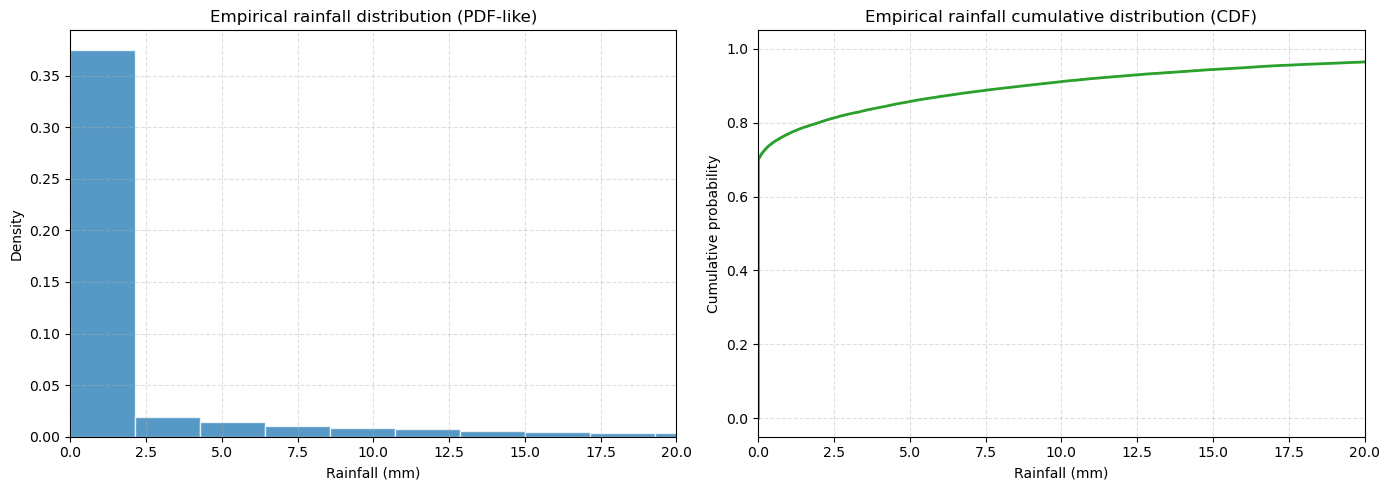

In [42]:
# Probability distribution of rainfall across the whole basin (all catchments pooled)
prec_all_basins = Prec.iloc[:, :5].apply(pd.to_numeric, errors="coerce")
rain_all = prec_all_basins.to_numpy().ravel()
rain_all = rain_all[np.isfinite(rain_all)]
rain_all = rain_all[rain_all >= 0]

if rain_all.size == 0:
    raise ValueError("No valid rainfall values found in precipitation data.")

# Summary statistics
rain_summary = pd.Series(rain_all).describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print("Rainfall summary across all basins (mm):")
display(rain_summary.to_frame(name="Value"))

# Empirical PDF (histogram) and CDF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PDF-like histogram
axes[0].hist(rain_all, bins=60, density=True, color="tab:blue", alpha=0.75, edgecolor="white")
axes[0].set_title("Empirical rainfall distribution (PDF-like)")
axes[0].set_xlabel("Rainfall (mm)")
axes[0].set_ylabel("Density")
axes[0].set_xlim(0, 20)
axes[0].grid(True, linestyle="--", alpha=0.4)

# Empirical CDF
rain_sorted = np.sort(rain_all)
cdf = np.arange(1, rain_sorted.size + 1) / rain_sorted.size
axes[1].plot(rain_sorted, cdf, color="tab:green", linewidth=2)
axes[1].set_title("Empirical rainfall cumulative distribution (CDF)")
axes[1].set_xlabel("Rainfall (mm)")
axes[1].set_ylabel("Cumulative probability")
axes[1].set_xlim(0, 20)
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Rainfall summary for Catchment 4 (mm):


,Value
count,11686.000000
mean,1.697318
std,5.757380
min,0.000000
10%,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
90%,4.704000
95%,12.201000


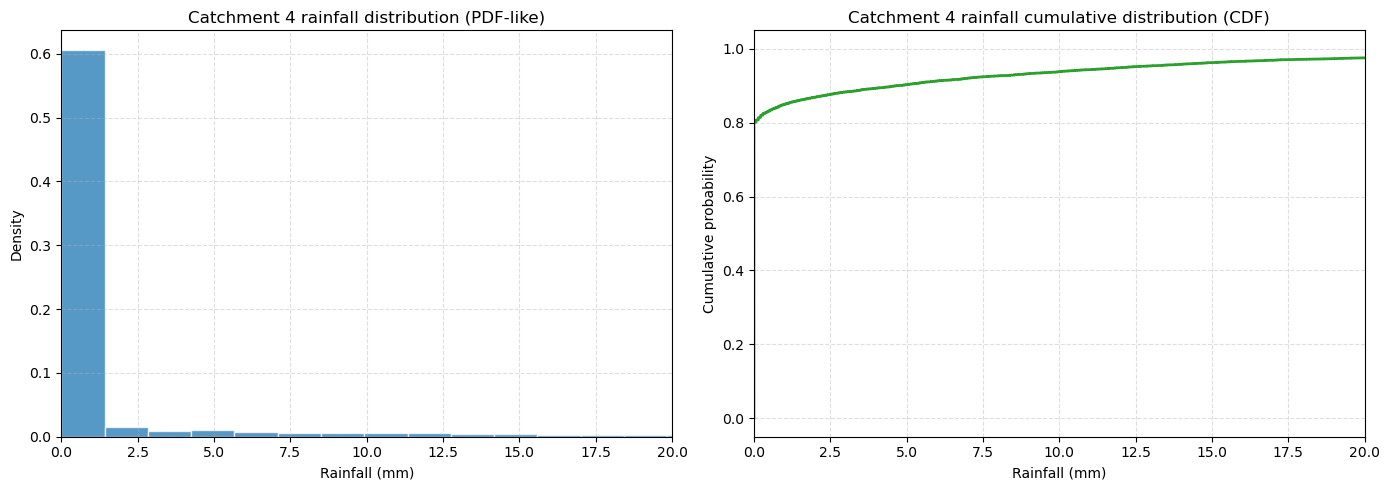

In [43]:
# Probability distribution of rainfall for Catchment 4 only
catchment_4_col = Prec.columns[1]  # order assumed: C5, C4, C3, C2, C1
rain_c4 = pd.to_numeric(Prec[catchment_4_col], errors="coerce")
rain_c4 = rain_c4[np.isfinite(rain_c4)]
rain_c4 = rain_c4[rain_c4 >= 0]

if rain_c4.size == 0:
    raise ValueError("No valid rainfall values found for Catchment 4.")

# Summary statistics
rain_c4_summary = pd.Series(rain_c4).describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print("Rainfall summary for Catchment 4 (mm):")
display(rain_c4_summary.to_frame(name="Value"))

# Empirical PDF (histogram) and CDF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PDF-like histogram
axes[0].hist(rain_c4, bins=60, density=True, color="tab:blue", alpha=0.75, edgecolor="white")
axes[0].set_title("Catchment 4 rainfall distribution (PDF-like)")
axes[0].set_xlabel("Rainfall (mm)")
axes[0].set_ylabel("Density")
axes[0].set_xlim(0, 20)
axes[0].grid(True, linestyle="--", alpha=0.4)

# Empirical CDF
rain_c4_sorted = np.sort(rain_c4)
cdf_c4 = np.arange(1, rain_c4_sorted.size + 1) / rain_c4_sorted.size
axes[1].plot(rain_c4_sorted, cdf_c4, color="tab:green", linewidth=2)
axes[1].set_title("Catchment 4 rainfall cumulative distribution (CDF)")
axes[1].set_xlabel("Rainfall (mm)")
axes[1].set_ylabel("Cumulative probability")
axes[1].set_xlim(0, 20)
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

PROBABILITY DISTRIBUTION WET SEASON

Wet-season rainfall summary across all basins (March-November, mm):


,Value
count,43999.000000
mean,3.325541
std,7.767941
min,0.000000
10%,0.000000
25%,0.000000
50%,0.000000
75%,2.402284
90%,11.757785
95%,19.316171


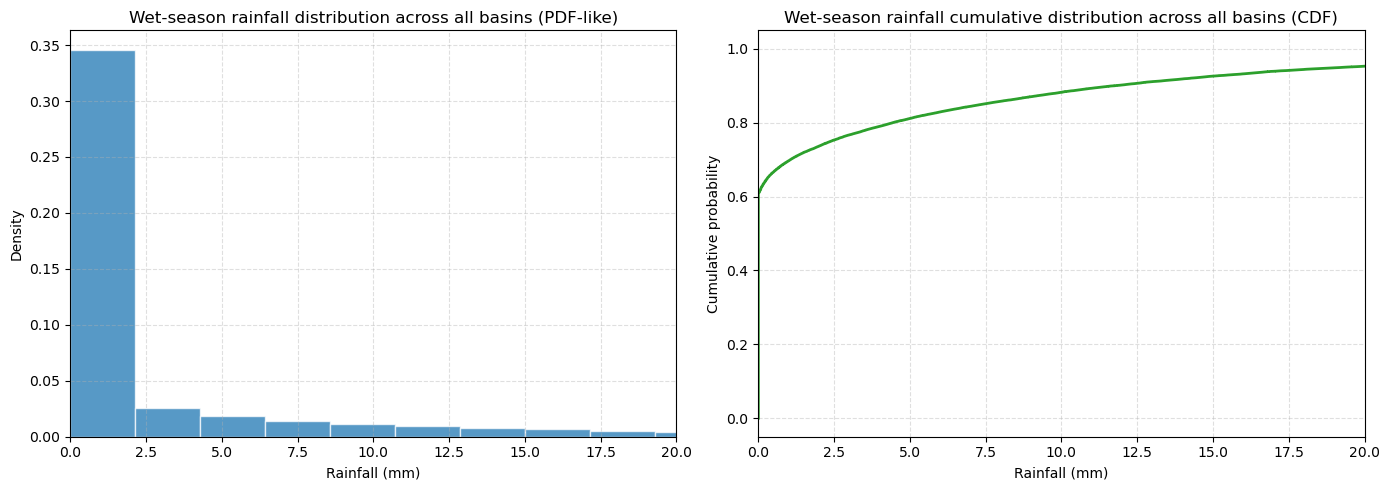

In [44]:
# Probability distribution of rainfall across all basins during wet season (March-November)
wet_months = [3, 4, 5, 6, 7, 8, 9, 10, 11]
prec_wet = Prec.loc[Prec.index.month.isin(wet_months), Prec.columns[:5]].apply(pd.to_numeric, errors="coerce")

rain_wet_all = prec_wet.to_numpy().ravel()
rain_wet_all = rain_wet_all[np.isfinite(rain_wet_all)]
rain_wet_all = rain_wet_all[rain_wet_all >= 0]

if rain_wet_all.size == 0:
    raise ValueError("No valid wet-season rainfall values found for all basins.")

# Summary statistics
rain_wet_summary = pd.Series(rain_wet_all).describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print("Wet-season rainfall summary across all basins (March-November, mm):")
display(rain_wet_summary.to_frame(name="Value"))

# Empirical PDF (histogram) and CDF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PDF-like histogram
axes[0].hist(rain_wet_all, bins=60, density=True, color="tab:blue", alpha=0.75, edgecolor="white")
axes[0].set_title("Wet-season rainfall distribution across all basins (PDF-like)")
axes[0].set_xlabel("Rainfall (mm)")
axes[0].set_ylabel("Density")
axes[0].set_xlim(0, 20)
axes[0].grid(True, linestyle="--", alpha=0.4)

# Empirical CDF
rain_wet_sorted = np.sort(rain_wet_all)
cdf_wet = np.arange(1, rain_wet_sorted.size + 1) / rain_wet_sorted.size
axes[1].plot(rain_wet_sorted, cdf_wet, color="tab:green", linewidth=2)
axes[1].set_title("Wet-season rainfall cumulative distribution across all basins (CDF)")
axes[1].set_xlabel("Rainfall (mm)")
axes[1].set_ylabel("Cumulative probability")
axes[1].set_xlim(0, 20)
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

non linear analysis

In [45]:
# Framework: seasonal cumulative precipitation and discharge for non-linear analysis
basin_area_km2 = 131000
basin_area_m2 = basin_area_km2 * 1e6

# Valid years requested for Chache analysis
valid_years = list(range(2000, 2011)) + list(range(2013, 2024))

# Use Chache discharge and first 5 precipitation columns (order assumed: C5, C4, C3, C2, C1)
q_col = Data_Chance.select_dtypes(include=[np.number]).columns[0]
q_raw = Data_Chance[[q_col]].rename(columns={q_col: "Q_chache_m3s"}).copy()
p_cols_raw = list(Prec.columns[:5])
p_raw = Prec[p_cols_raw].apply(pd.to_numeric, errors="coerce").copy()

# Rename precipitation columns to explicit catchment labels
p_raw.columns = ["P_C5_mm", "P_C4_mm", "P_C3_mm", "P_C2_mm", "P_C1_mm"]

def assign_season_and_year(df):
    out = df.copy()
    month = out.index.month
    year = out.index.year

    # Non-overlapping month assignment from requested boundaries:
    # dry: Nov-Feb, early_peak: Mar-Jun, wet: Jul-Oct
    season = np.select(
        [month.isin([11, 12, 1, 2]), month.isin([3, 4, 5, 6]), month.isin([7, 8, 9, 10])],
        ["dry", "early_peak", "wet"],
        default=None
    )

    season_year = year.copy()
    season_year = np.where(month.isin([11, 12]), season_year + 1, season_year)

    out["season"] = season
    out["season_year"] = season_year
    return out

# Build seasonal discharge table
q_seasonal = assign_season_and_year(q_raw)
q_seasonal = q_seasonal[q_seasonal["season_year"].isin(valid_years) & q_seasonal["season"].notna()]
q_seasonal = q_seasonal.groupby(["season_year", "season"], as_index=False)["Q_chache_m3s"].sum()
q_seasonal["Q_cum_volume_m3"] = q_seasonal["Q_chache_m3s"] * 86400
q_seasonal["Q_cum_depth_mm_over_basin"] = q_seasonal["Q_cum_volume_m3"] / basin_area_m2 * 1000

# Build seasonal precipitation table
p_seasonal = assign_season_and_year(p_raw)
p_seasonal = p_seasonal[p_seasonal["season_year"].isin(valid_years) & p_seasonal["season"].notna()]
p_sum_cols = ["P_C5_mm", "P_C4_mm", "P_C3_mm", "P_C2_mm", "P_C1_mm"]
p_seasonal = p_seasonal.groupby(["season_year", "season"], as_index=False)[p_sum_cols].sum()
p_seasonal["P_cum_basin_mean_mm"] = p_seasonal[p_sum_cols].mean(axis=1)

# Merge into one framework dataframe
seasonal_framework_df = pd.merge(
    p_seasonal,
    q_seasonal[["season_year", "season", "Q_cum_volume_m3", "Q_cum_depth_mm_over_basin"]],
    on=["season_year", "season"],
    how="inner"
)

# Order seasons for readability
season_order = pd.CategoricalDtype(["dry", "early_peak", "wet"], ordered=True)
seasonal_framework_df["season"] = seasonal_framework_df["season"].astype(season_order)
seasonal_framework_df = seasonal_framework_df.sort_values(["season_year", "season"]).reset_index(drop=True)

display(seasonal_framework_df.head(12))
seasonal_framework_df

,season_year,season,P_C5_mm,P_C4_mm,P_C3_mm,P_C2_mm,P_C1_mm,P_cum_basin_mean_mm,Q_cum_volume_m3,Q_cum_depth_mm_over_basin
0,2000,dry,5.131368,0.8820,0.920862,23.127946,88.191176,23.650671,1.301114e+08,0.993217
1,2000,early_peak,297.338482,127.5960,207.307820,346.323362,504.201398,296.553412,1.873445e+08,1.430111
2,2000,wet,766.531710,298.4100,489.282500,701.250981,629.674214,577.029881,2.638025e+09,20.137592
3,2001,dry,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,3.070396e+08,2.343814
4,2001,early_peak,235.266675,185.7345,228.270235,265.421976,334.432077,249.825093,2.521697e+08,1.924959
5,2001,wet,697.688016,410.8650,546.271758,657.197816,625.012363,587.406991,1.968088e+09,15.023573
6,2002,dry,4.196851,0.0000,0.000000,2.363786,0.352941,1.382715,1.462044e+08,1.116064
7,2002,early_peak,244.854838,100.8420,152.607340,183.348811,250.371597,186.404917,1.726443e+08,1.317896
8,2002,wet,623.268491,446.5860,568.677078,627.006978,660.452366,585.198183,1.837415e+09,14.026067
9,2003,dry,0.000000,0.0000,1.230123,10.022446,45.764706,11.403455,9.647629e+07,0.736460


,season_year,season,P_C5_mm,P_C4_mm,P_C3_mm,P_C2_mm,P_C1_mm,P_cum_basin_mean_mm,Q_cum_volume_m3,Q_cum_depth_mm_over_basin
0,2000,dry,5.131368,0.8820,0.920862,23.127946,88.191176,23.650671,1.301114e+08,0.993217
1,2000,early_peak,297.338482,127.5960,207.307820,346.323362,504.201398,296.553412,1.873445e+08,1.430111
2,2000,wet,766.531710,298.4100,489.282500,701.250981,629.674214,577.029881,2.638025e+09,20.137592
3,2001,dry,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,3.070396e+08,2.343814
4,2001,early_peak,235.266675,185.7345,228.270235,265.421976,334.432077,249.825093,2.521697e+08,1.924959
...,...,...,...,...,...,...,...,...,...,...
59,2021,wet,816.508410,461.7270,569.998852,790.084805,938.084147,715.280643,6.813525e+09,52.011641
60,2022,dry,20.086648,1.6170,4.603225,29.261141,26.352941,16.384191,3.358810e+08,2.563977
61,2022,early_peak,300.023337,153.7620,274.471138,373.900000,350.066455,290.444586,5.541657e+08,4.230273
62,2022,wet,548.786113,498.0360,594.754651,870.950000,818.253864,666.156126,7.688907e+09,58.693949
